In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string
import re

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

reviews = pd.read_csv("../data/raw/reviews.csv")

print(reviews.shape)
print(reviews.head())
print(reviews.info())

(54001, 6)
  review_id order_id customer_id  review_rating  \
0  RV000001  O089133     C005079              4   
1  RV000002  O013863     C004885              5   
2  RV000003  O059312     C004955              4   
3  RV000004  O086506     C000669              3   
4  RV000005  O073707     C002424              5   

                                         review_text     review_timestamp  
0        Really happy with the delivery and service.  2025-06-14 16:27:00  
1        Really happy with the delivery and service.  2025-06-29 22:47:00  
2          Great experience, the food was delicious.  2025-11-24 12:47:00  
3  Average experience. Nothing particularly good ...  2025-09-05 21:42:00  
4                Excellent food and smooth delivery.  2026-02-08 10:01:00  
<class 'pandas.DataFrame'>
RangeIndex: 54001 entries, 0 to 54000
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   review_id         54001 non-null  

In [6]:
print("Missing values:")
print(reviews.isnull().sum())

print("\nDuplicate rows:")
print(reviews.duplicated().sum())

print("\nRating distribution:")
print(reviews["review_rating"].value_counts().sort_index())

print("\nSample reviews:")
print(reviews[["review_rating", "review_text"]].head(10))

Missing values:
review_id           0
order_id            0
customer_id         0
review_rating       0
review_text         0
review_timestamp    0
dtype: int64

Duplicate rows:
0

Rating distribution:
review_rating
1     3180
2     8833
3    15214
4    15693
5    11081
Name: count, dtype: int64

Sample reviews:
   review_rating                                        review_text
0              4        Really happy with the delivery and service.
1              5        Really happy with the delivery and service.
2              4          Great experience, the food was delicious.
3              3  Average experience. Nothing particularly good ...
4              5                Excellent food and smooth delivery.
5              5                 The order arrived hot and on time.
6              4        Really happy with the delivery and service.
7              4                Excellent food and smooth delivery.
8              3  Average experience. Nothing particularly good ...
9     

In [8]:
# Create sentiment labels from review ratings

def create_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"


reviews["sentiment"] = reviews["review_rating"].apply(
    create_sentiment
)

print("Sentiment distribution:")
print(reviews["sentiment"].value_counts())

print("\nSentiment percentages:")
print(
    reviews["sentiment"]
    .value_counts(normalize=True)
    .round(3)
)

Sentiment distribution:
sentiment
positive    26774
neutral     15214
negative    12013
Name: count, dtype: int64

Sentiment percentages:
sentiment
positive    0.496
neutral     0.282
negative    0.222
Name: proportion, dtype: float64


In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword removal + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
        and word.isalpha()
    ]

    return " ".join(tokens)


reviews["clean_text"] = reviews["review_text"].apply(clean_text)

print(
    reviews[
        ["review_text", "clean_text", "sentiment"]
    ].head(10)
)

                                         review_text  \
0        Really happy with the delivery and service.   
1        Really happy with the delivery and service.   
2          Great experience, the food was delicious.   
3  Average experience. Nothing particularly good ...   
4                Excellent food and smooth delivery.   
5                 The order arrived hot and on time.   
6        Really happy with the delivery and service.   
7                Excellent food and smooth delivery.   
8  Average experience. Nothing particularly good ...   
9        Really happy with the delivery and service.   

                                         clean_text sentiment  
0                     really happy delivery service  positive  
1                     really happy delivery service  positive  
2                   great experience food delicious  positive  
3  average experience nothing particularly good bad   neutral  
4                    excellent food smooth delivery  positive  

In [10]:
X = reviews["clean_text"]
y = reviews["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 43200
Testing samples: 10801


In [12]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (43200, 87)
Testing TF-IDF shape: (10801, 87)


In [13]:
feature_names = np.array(tfidf.get_feature_names_out())

mean_tfidf = X_train_tfidf.mean(axis=0).A1

top_indices = mean_tfidf.argsort()[-30:][::-1]

top_words = pd.DataFrame({
    "word": feature_names[top_indices],
    "tfidf_score": mean_tfidf[top_indices]
})

top_words

,word,tfidf_score
0,food,0.103948
1,delivery,0.084313
2,experience,0.080560
3,arrived,0.069270
4,fresh,0.052469
5,food fresh,0.052469
6,order,0.045896
7,excellent,0.042514
8,food smooth,0.042514
9,smooth,0.042514


In [14]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred = nb_model.predict(X_test_tfidf)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00      2403
     neutral       1.00      1.00      1.00      3043
    positive       1.00      1.00      1.00      5355

    accuracy                           1.00     10801
   macro avg       1.00      1.00      1.00     10801
weighted avg       1.00      1.00      1.00     10801



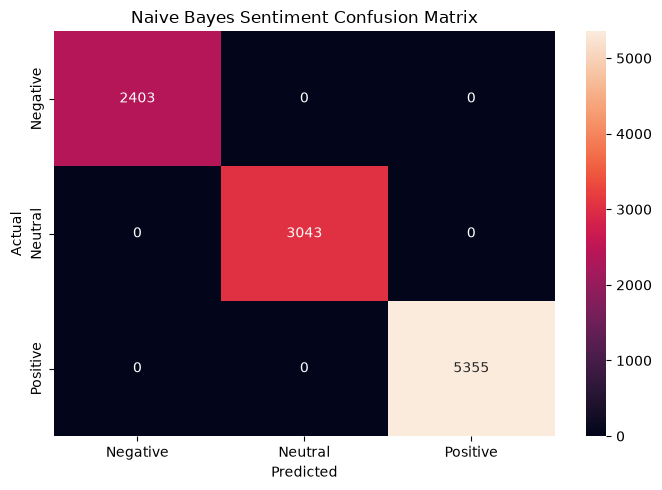

In [16]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Naive Bayes Sentiment Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [17]:
analyzer = SentimentIntensityAnalyzer()


def vader_sentiment(text):

    score = analyzer.polarity_scores(str(text))

    compound = score["compound"]

    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"


reviews["vader_sentiment"] = (
    reviews["review_text"]
    .apply(vader_sentiment)
)

print(
    reviews["vader_sentiment"].value_counts()
)

vader_sentiment
positive    27549
negative    13372
neutral     13080
Name: count, dtype: int64


In [18]:
vader_accuracy = accuracy_score(
    reviews["sentiment"],
    reviews["vader_sentiment"]
)

vader_precision = precision_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

vader_recall = recall_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

vader_f1 = f1_score(
    reviews["sentiment"],
    reviews["vader_sentiment"],
    average="weighted"
)

print("VADER Accuracy :", round(vader_accuracy, 4))
print("VADER Precision:", round(vader_precision, 4))
print("VADER Recall   :", round(vader_recall, 4))
print("VADER F1       :", round(vader_f1, 4))

VADER Accuracy : 0.5887
VADER Precision: 0.5731
VADER Recall   : 0.5887
VADER F1       : 0.5801


In [19]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Naive Bayes",
        "VADER"
    ],
    "Accuracy": [
        accuracy,
        vader_accuracy
    ],
    "Precision": [
        precision,
        vader_precision
    ],
    "Recall": [
        recall,
        vader_recall
    ],
    "F1 Score": [
        f1,
        vader_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Naive Bayes,1.0000,1.0000,1.0000,1.0000
1,VADER,0.5887,0.5731,0.5887,0.5801


In [20]:
negative_reviews = reviews[
    reviews["sentiment"] == "negative"
]

print(
    negative_reviews[
        ["review_rating", "review_text"]
    ].head(20)
)

     review_rating                                        review_text
13               1  The delivery was delayed and the food was not ...
14               2                     Very disappointing experience.
15               2             The order took far too long to arrive.
18               2                     Very disappointing experience.
19               1  The delivery was delayed and the food was not ...
27               2             The order took far too long to arrive.
29               2                         The food quality was poor.
34               1             The order took far too long to arrive.
39               1                         The food quality was poor.
50               2                     Very disappointing experience.
56               1                     Very disappointing experience.
68               2                     Very disappointing experience.
72               2  The delivery was delayed and the food was not ...
74               2  

In [21]:
negative_tfidf = TfidfVectorizer(
    max_features=30,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

negative_matrix = negative_tfidf.fit_transform(
    negative_reviews["review_text"].astype(str)
)

negative_features = np.array(
    negative_tfidf.get_feature_names_out()
)

negative_scores = negative_matrix.mean(axis=0).A1

negative_indices = (
    negative_scores.argsort()[-30:][::-1]
)

negative_keywords = pd.DataFrame({
    "keyword": negative_features[negative_indices],
    "score": negative_scores[negative_indices]
})

negative_keywords

,keyword,score
0,food,0.144037
1,experience,0.118229
2,disappointing experience,0.118229
3,disappointing,0.118229
4,delivery,0.111775
5,quality,0.096185
6,poor,0.096185
7,food quality,0.096185
8,quality poor,0.096185
9,delivery delayed,0.082514


In [22]:
reviews[
    [
        "review_id",
        "order_id",
        "customer_id",
        "review_rating",
        "review_text",
        "review_timestamp",
        "sentiment",
        "clean_text",
        "vader_sentiment"
    ]
].to_csv(
    "../data/processed/reviews_sentiment.csv",
    index=False
)

print("Saved reviews_sentiment.csv")

Saved reviews_sentiment.csv


In [23]:
# Check whether sentiment language is strongly tied to the rating

print(
    reviews.groupby("review_rating")["review_text"]
    .apply(lambda x: " | ".join(x.astype(str).head(3)))
)

review_rating
1    The delivery was delayed and the food was not ...
2    Very disappointing experience. | The order too...
3    Average experience. Nothing particularly good ...
4    Really happy with the delivery and service. | ...
5    Really happy with the delivery and service. | ...
Name: review_text, dtype: str


In [24]:
print(
    reviews.groupby("sentiment")["clean_text"]
    .apply(lambda x: " ".join(x.astype(str)).split()[:30])
)

sentiment
negative    [delivery, delayed, food, fresh, disappointing...
neutral     [average, experience, nothing, particularly, g...
positive    [really, happy, delivery, service, really, hap...
Name: clean_text, dtype: object


In [25]:
reviews[
    [
        "review_id",
        "order_id",
        "customer_id",
        "review_rating",
        "review_text",
        "review_timestamp",
        "sentiment",
        "clean_text",
        "vader_sentiment"
    ]
].to_csv(
    "../data/processed/reviews_sentiment.csv",
    index=False
)